In [1]:
%matplotlib inline
import jax.numpy as jnp
import matplotlib.pyplot as plt


# important imports 
import sys
sys.path.insert(0, "../")  
from TOOL_BOX_OF_FUNCTIONS.GAUSSIAN_PROCESSES_REGRESSION import GP_REGRESSION as GP 

## Preparing the data and the model 

In [2]:
x = jnp.array([-2.17, 1.99, 0.57, -3.01, -1.16, 3.30, -4.85, -0.86]).reshape(-1, 1) # need to reshape to (n, 1)
print(f"Shape of X: {x.shape}")
y = jnp.array([0.88 ,0.46 ,-0.06, 0.98, 0.45,0.88 ,-0.66, 0.05])[:, None]  
print(f"Shape of y: {y.shape}")

# hyperparemeters
kappa = 0.7 
ell = 0.5 * jnp.sqrt(2)
sigma = 1/5


# Define the kernel 
kernel = GP.StationaryIsotropicKernel(kernel_fun=GP.squared_exponential, kappa=kappa, lengthscale=ell)

# define the model 
GP_ = GP.GaussianProcessRegression(X=x, y=y, kernel=kernel, kappa=kappa, lengthscale=ell, sigma=sigma)

Shape of X: (8, 1)
Shape of y: (8, 1)


## Question 2.2 Determine the analytical prior prediciton distribution $p(y^* |x^* = 1)$ for $y^* = y(x^*)$

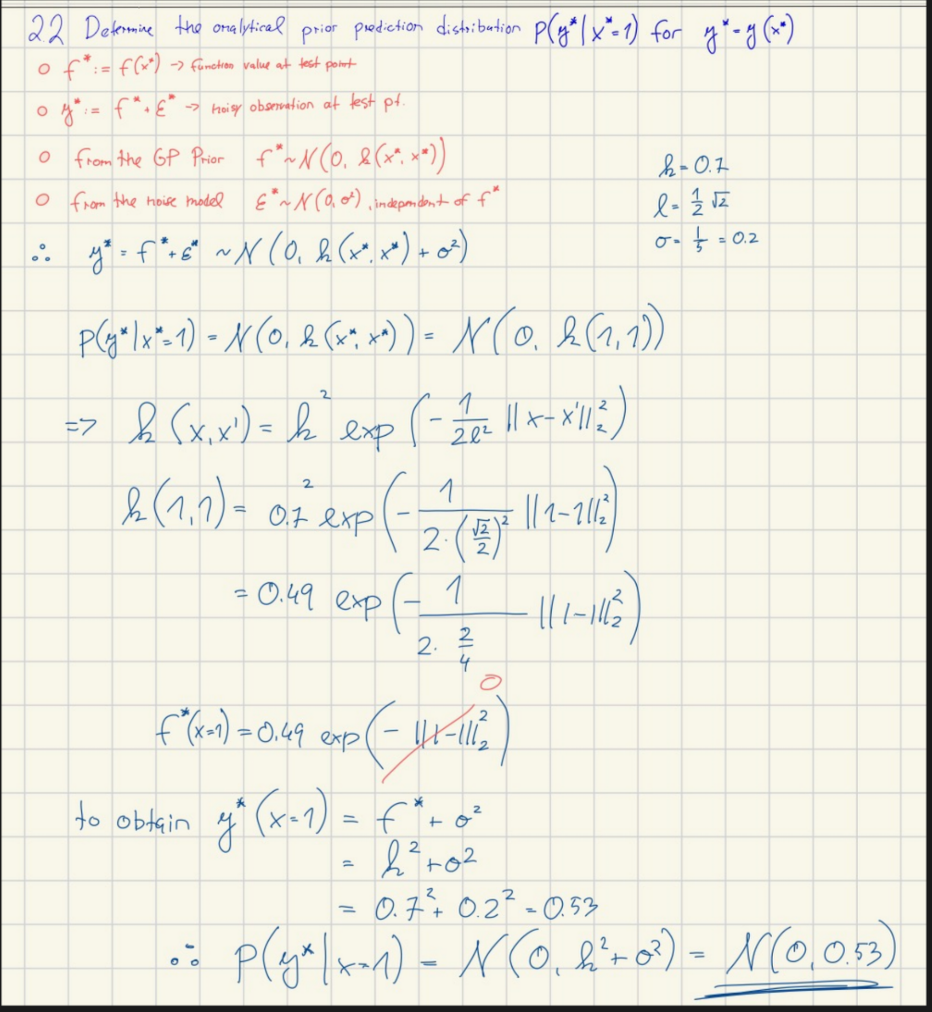

### Solution with the **Gaussian Process Regression Class** 

In [3]:
print(f"Prior pred mean of y*: {prior_pred_y_mean.item():3.2f}")
print(f"Prior pred var of y*: {prior_pred_y_var.item():3.2f}")

print(f"Prior pred mean of f*: {pror_pred_f_mean.item():3.2f}")
print(f"Prior pred var of f*: {prior_pred_f_mean.item():3.2f}")


NameError: name 'prior_pred_y_mean' is not defined

### Teachers solution (using what we have obtained in hand)

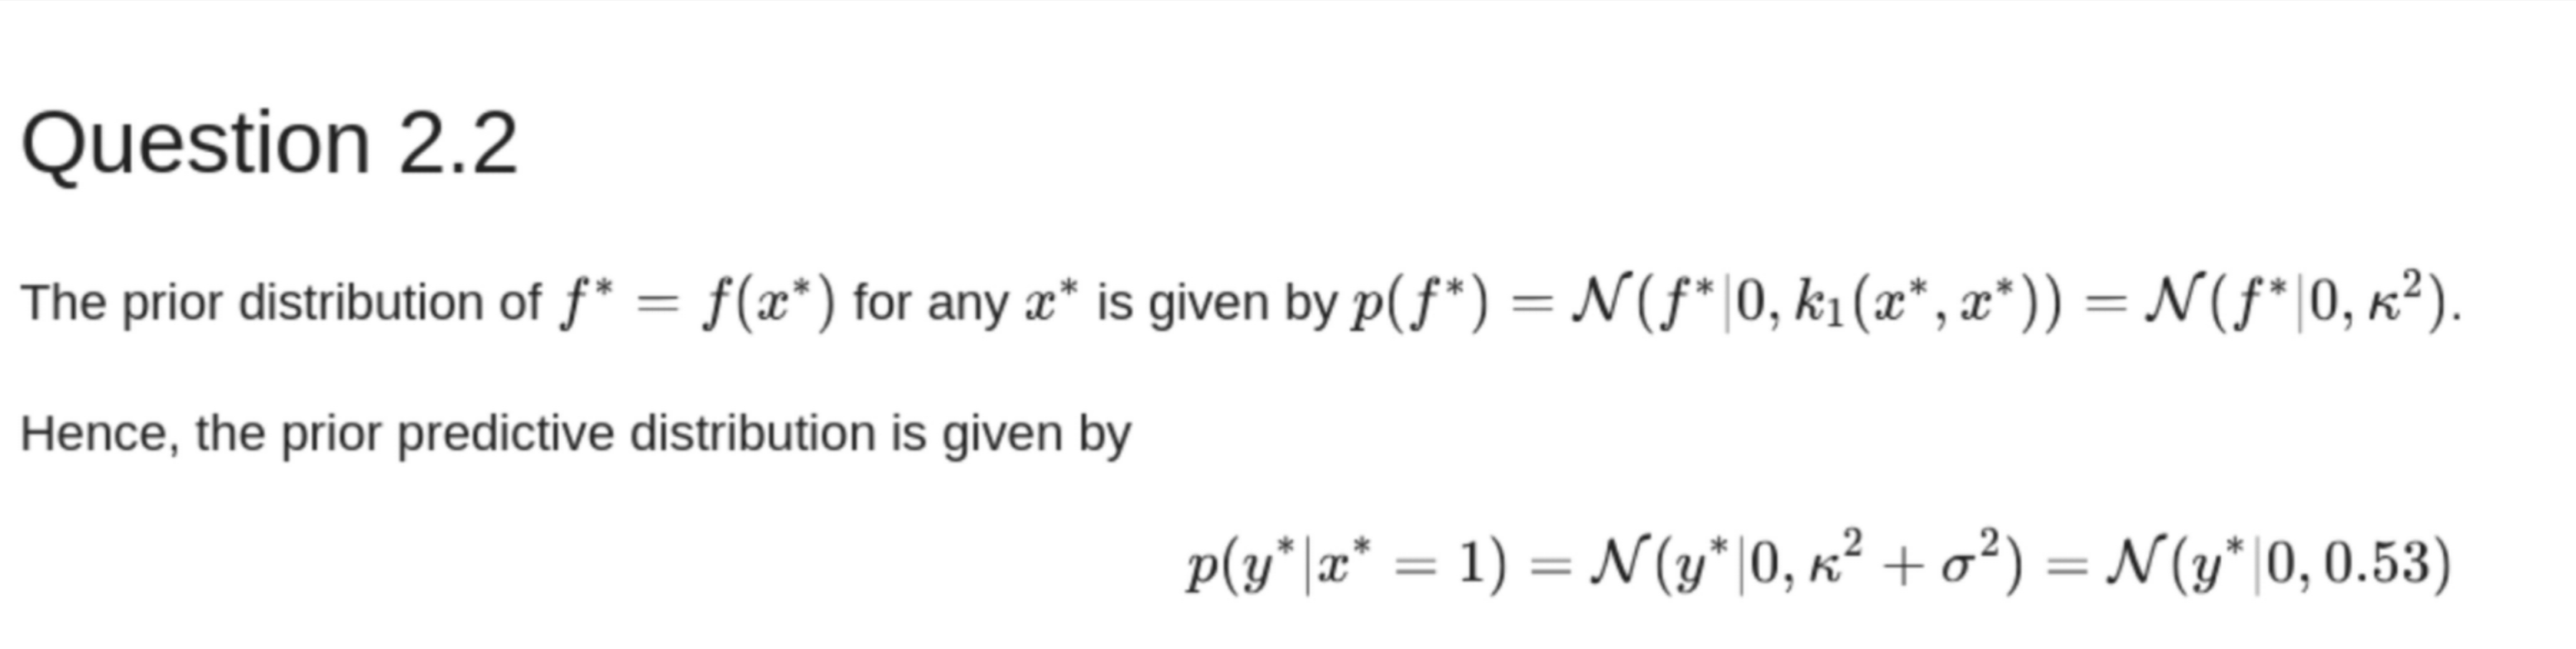

**Gaussian Process Prior and Prior Predictive Distribution**

*Prior over function values*
In GP regression, the first thing we always model is the distribution over the $\textbf{functional values}$, not the observations, which means:
$$
f^* = f(x^*) \sim \mathcal{N}(0, k(x^*, x^*)) = \mathcal{N}(0, \kappa^2)
$$
This is a $\textbf{pure function}$ under the GP prior — $\textbf{no noise yet!}$  

*Observational noise*
$\textbf{Observational noise:}$  
The actual observed output at $x^*$ is not $f^*$; it's:
$$
y^* = f^* + \epsilon, \quad \text{with} \quad \epsilon \sim \mathcal{N}(0, \sigma^2)
$$
Since $f^*$ and $\epsilon$ are independent Gaussians, their sum is also Gaussian:
$$
y^* \sim \mathcal{N}(0, \kappa^2 + \sigma^2)
$$

*Prior predictive distribution*
So the $\textbf{prior predictive}$ over the noisy output is:
$$
p(y^* \mid x^*) = \mathcal{N}(0, \kappa^2 + \sigma^2)
$$



✅ **Why did the teacher focus on $f^*$?**

Because it is cleaner and pedagogically sound to first state the GP prior on the function, then add the noise model separately to get $y^*$.

This two-step process matches the GP regression generative story:

- $f \sim \mathcal{GP}(0, k(x, x'))$ 
- $y_n = f(x_n) + \epsilon_n \quad \text{with noise} \quad \epsilon_n \sim \mathcal{N}(0, \sigma^2)$

So the teacher’s write-up just follows this modeling logic — they calculate:

**First:**

- $p(f^*) = \mathcal{N}(0, \kappa^2)$

**Then:**

- $p(y^*) = \mathcal{N}(0, \kappa^2 + \sigma^2)$  

---

🔁 **In Summary**

- The teacher starts with the GP prior over function values $f^*$ because that’s the foundation of the model.

- Then they add observation noise $\epsilon^*$ to get the final predictive distribution for $y^*$.

- It’s just a clean separation of model components:  
  **first the signal, then the noise.**

### Teachers solution


In [ ]:
print(f"p(y^* | x^*=1) = N(y^*| 0, {kappa**2 + sigma**2:3.2f})")

p(y^* | x^*=1) = N(y^*| 0, 0.53)


__________________________

## Question 2.3: Determine the analytical posterior predictive distribution p(y*|y, x* = 227) for y* = y(x*).


In [ ]:
x_star = jnp.array([277])

mean_post, var_post = GP_.predict_y(x_star)

print(f"The posterior predictive distribution for p(y*|y, x*=277) = N({mean_post.item():.2f}, {var_post.item():.2f})")

The posterior predictive distribution for p(y*|y, x*=277) = N(0.00, 0.53)


**✅ Intuition**

This question is asking, "Given the observed data $y$  I have seen so far, how does the function behave at a new point $x^* = 227$?"

- The mean tells you the models best guess at $y^*$.
- The variance tells you th moodels uncertanity abotu the guess. Which goes down near training points an stays high away from training points reverting to the prior uncertainty.

**✨ Interpretation**
- if $x^* = 227$ is far from yout training data, the prediction will fall back toward the prior mean (which is 0 in this case) and the variance will be close to $\kappa^2 + \sigma^2$, i.e. the prior uncertainty.
- if $x^* = 227$ is close to your training data, the prediction will be more accurate, with a lower variance.

### Teachers solution

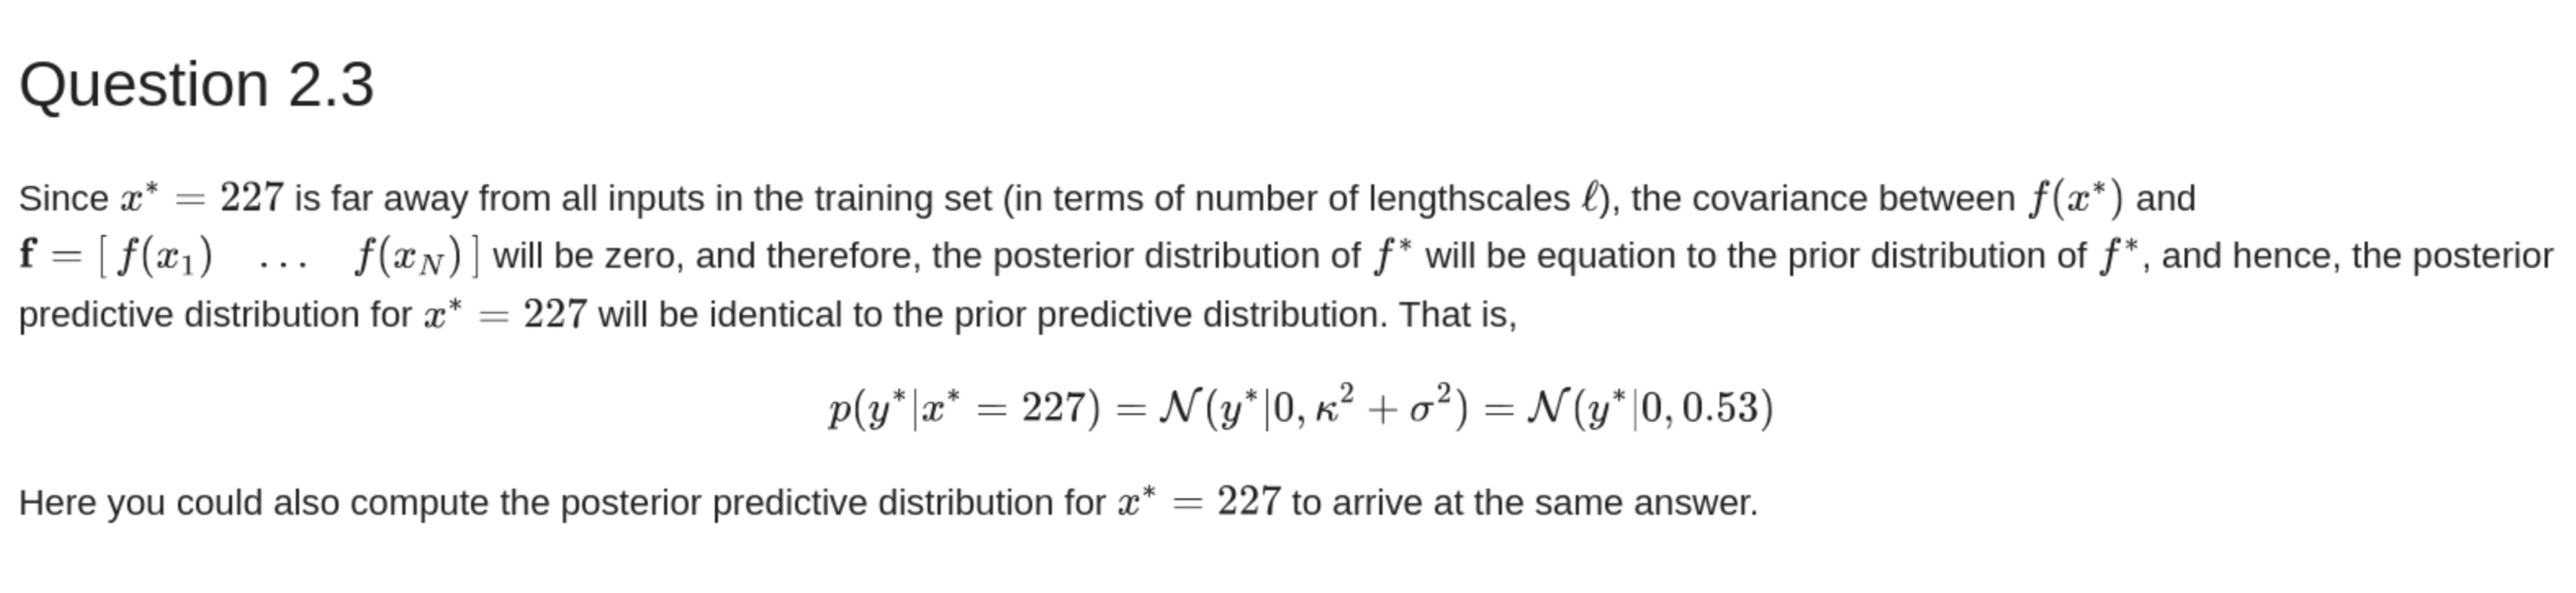

### Question 2.4: Determine the analytical expression for the marginal likelihood p(y|κ, ℓ, σ) and compute the numerical value of log p(y|κ, ℓ, σ).


In [ ]:
log_marginal = GP_.log_marginal_likelihood(kappa=kappa, lengthscale=ell, sigma=sigma)

print(f"The value of log marginal marginal likelihood log p(y) = {log_marginal:.2f} ")

The value of log marginal marginal likelihood log p(y) = -6.65 


**🧠 Intuition Behind the Log Marginal Likelihood** 
- **What does the marginal likelihood measure?**

   It measures how well your GP model (with the current hyperparameters) explains the observed data $y$.

- **It answers**:

 “If the function $f$ came from a GP with kernel $k(⋅,⋅;κ,ℓ)$ and noise $σ$, how probable is it that I would observe the actual data $y$ I saw?”

- **What does the value mean**

    We got: $\log p(y) = -6.65$. This means that the **density** assigned to your data **$y$** by the model is: $p(y) = e^{-6.65} \approx 0.0013$. This isn't a probability, but a density. This value is useful for comparing different models or hyperparameters.
     A **higher value** means the model explains the data well.
     A **lower value** means the model does not explain the data well.
     

### Teachers solution 

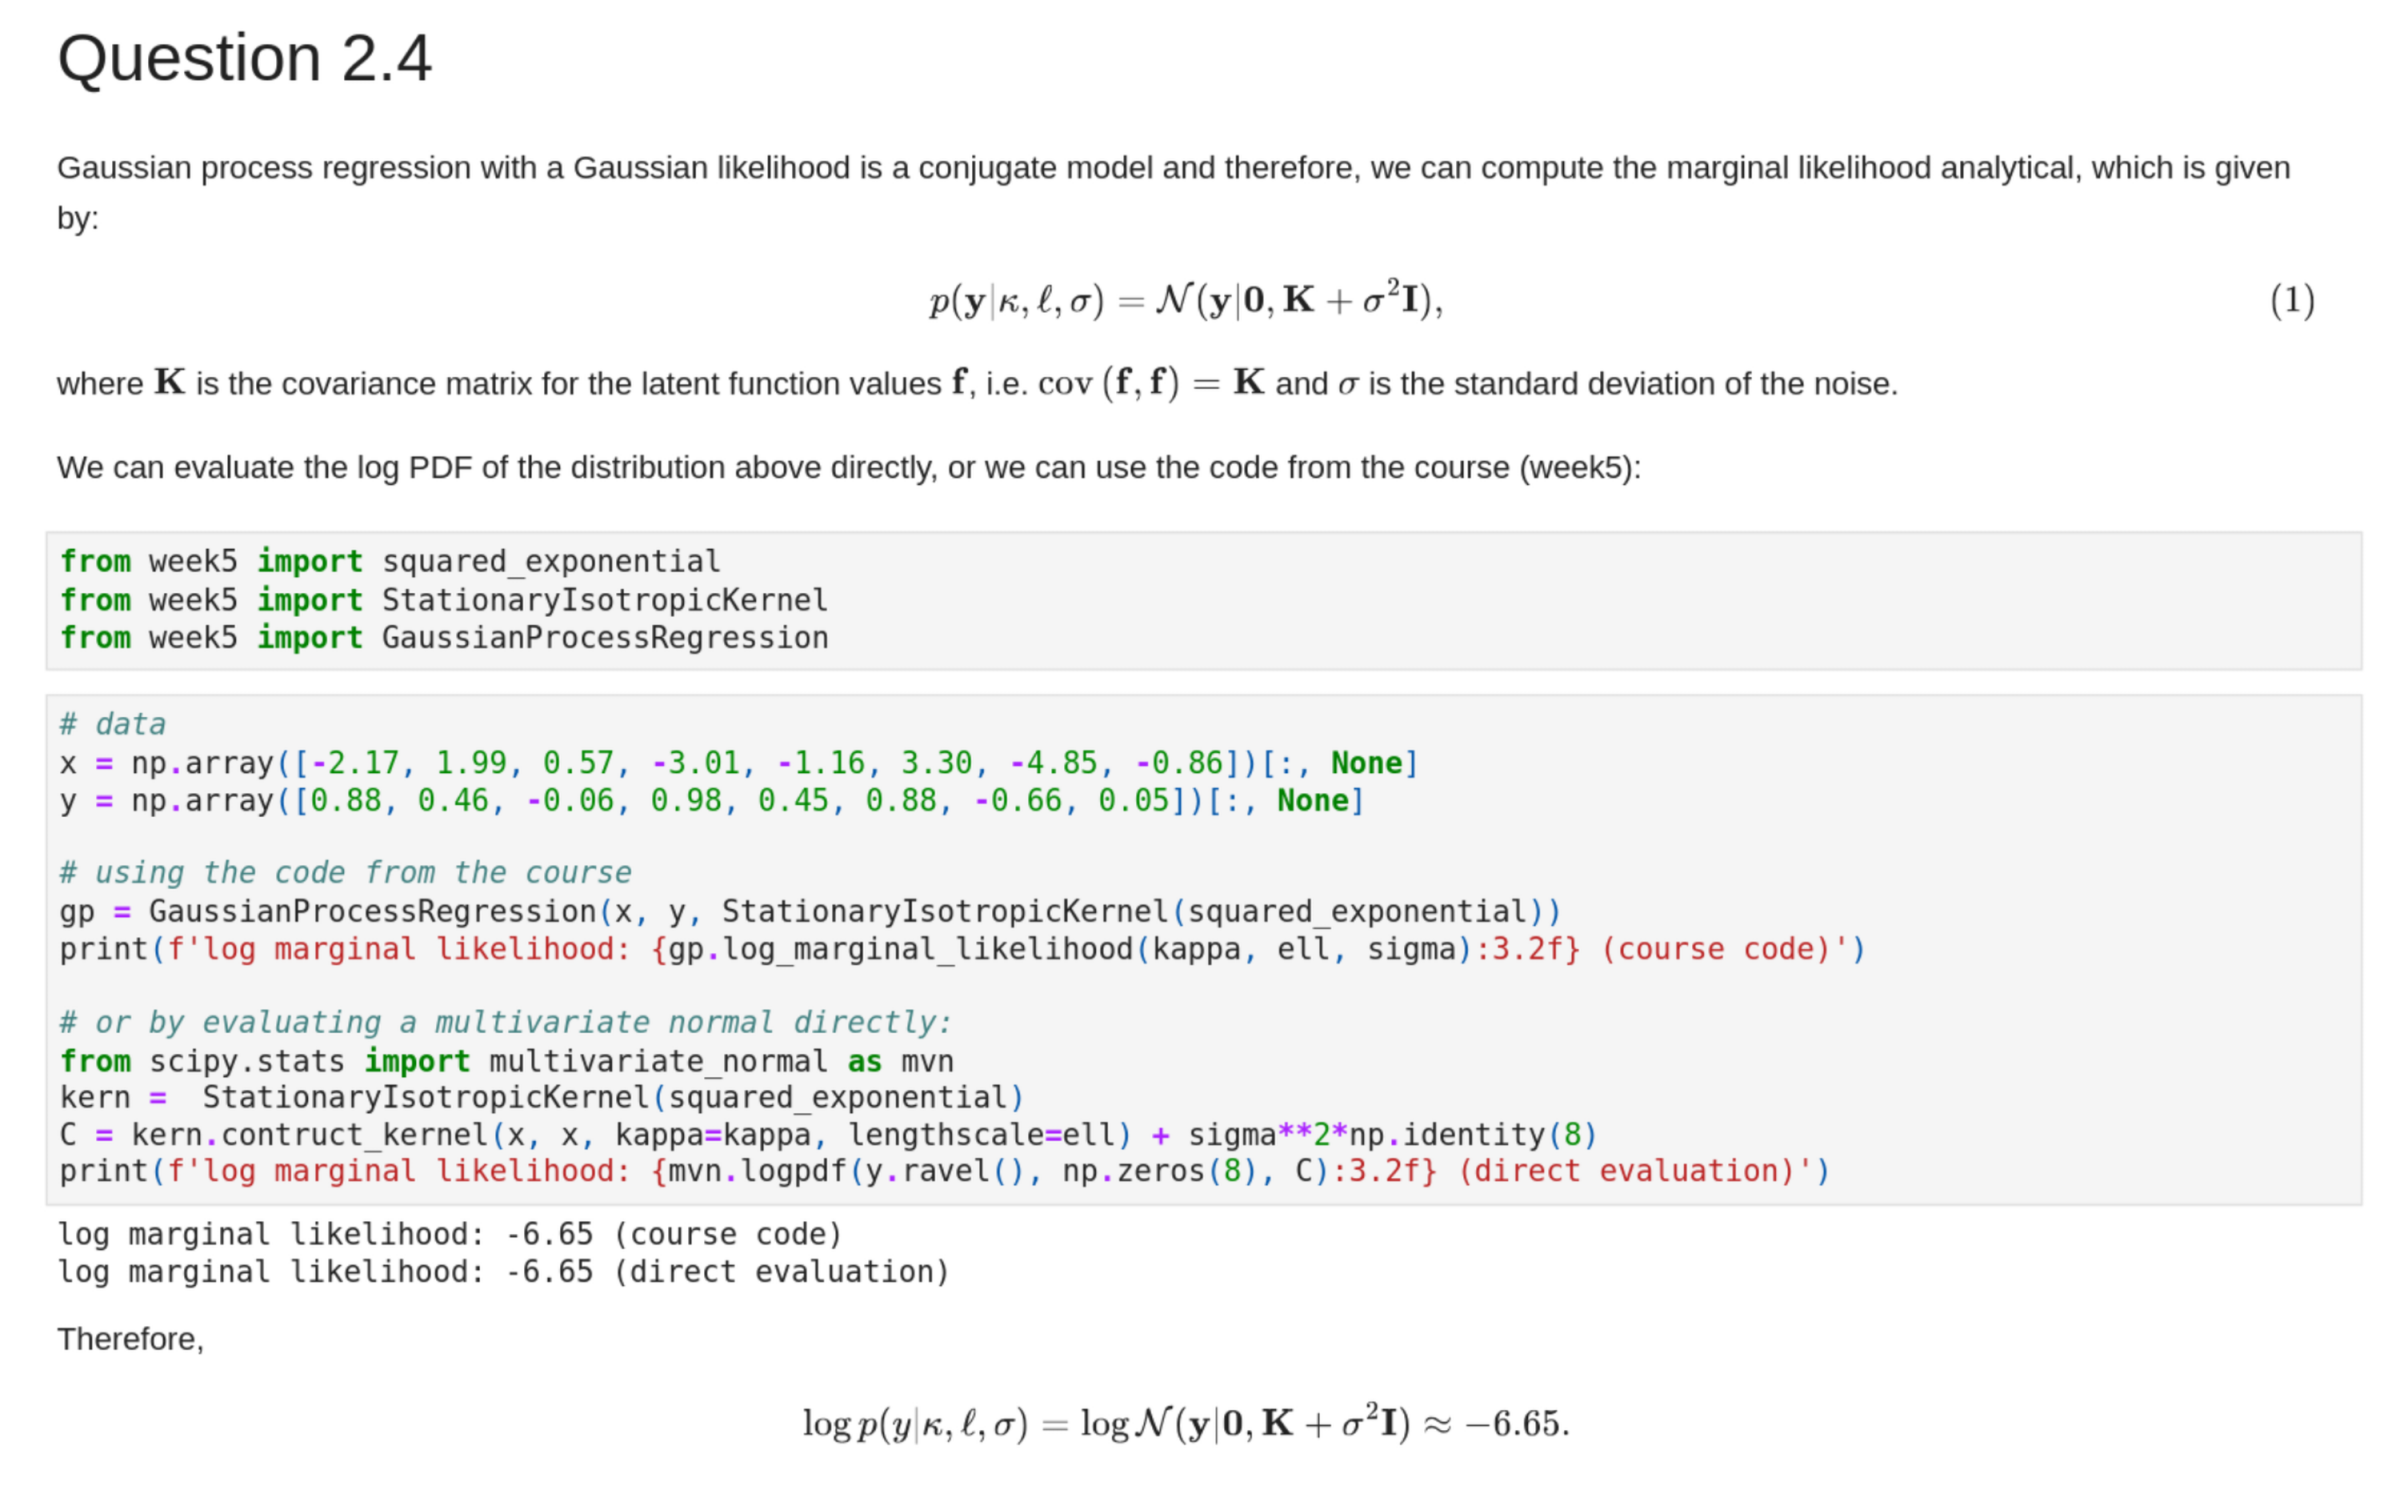

## Question 2.5: Determine the analytical posterior distribution p(f ∗ |y, x∗ = 1) for f ∗ = f (x∗) as well as the analytical posterior predictive distribution for p(y∗ |y, x∗ = 1) for y∗ = y(x∗ ).


In [ ]:
x_star = jnp.array([1])

mu_f, var_f = GP_.predict_f(Xstar=x_star)
print(f"The analytical posterior distribution p(f*|y, x*=1) = N(f*|{mu_f.item():.2f}, {var_f.item():.2f})")
mu_y, var_y = GP_.predict_y(Xstar=x_star)
print(f"The analytical posterior distribution p(y*|y, x*=1) = N(f*|{mu_y.item():.2f}, {var_y.item():.2f})")

The analytical posterior distribution p(f*|y, x*=1) = N(f*|0.07, 0.14)
The analytical posterior distribution p(y*|y, x*=1) = N(f*|0.07, 0.18)


## Question 2.7: Compute the prior covariance between $f = [f (x1), f (x2 ), . . . , f (x8)]$ and $f^* = f (x^*)$ for $x^* = −1$ for $c_1 = c_2 = 1$ and $\ell = \sqrt{1.2}$.

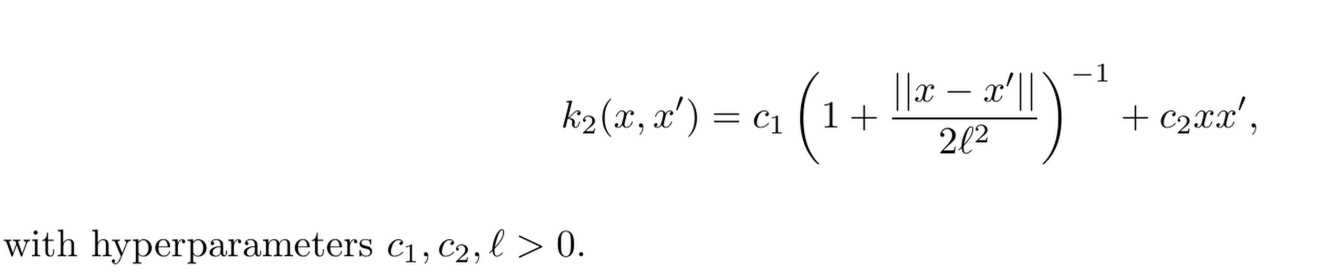

In [ ]:
def squared_exponential_2(x1, x2, c1, c2, lengthscale):
    return  (( 1 + jnp.abs(x1 - x2) / (2 * lengthscale**2))**(-1)) + x1 * x2 

In [ ]:
x_star = jnp.array([-1]).reshape(-1)
kernel2 = squared_exponential_2(x1=x, x2=x_star, c1=1, c2=1, lengthscale=jnp.sqrt(1/2))

# Print the kernel values with 2 decimal places
print(jnp.round(kernel2, 2))

[[ 2.63]
 [-1.74]
 [-0.18]
 [ 3.34]
 [ 2.02]
 [-3.11]
 [ 5.06]
 [ 1.74]]


### Teacher solution 

In [6]:
import numpy as np

# Define data
x = np.array([-2.17, 1.99, 0.57, -3.01, -1.16, 3.30, -4.85, -0.86])[:, None]



k2 = lambda x, xprime: 1./(1 + np.abs(x - xprime)) + x * xprime

xstar = np.array(-1)
for xn in x:
    print(f'{np.array2string(k2(xn, xstar), precision=2)}', end=', ')



[2.63], [-1.74], [-0.18], [3.34], [2.02], [-3.11], [5.06], [1.74], 

# Part 3 

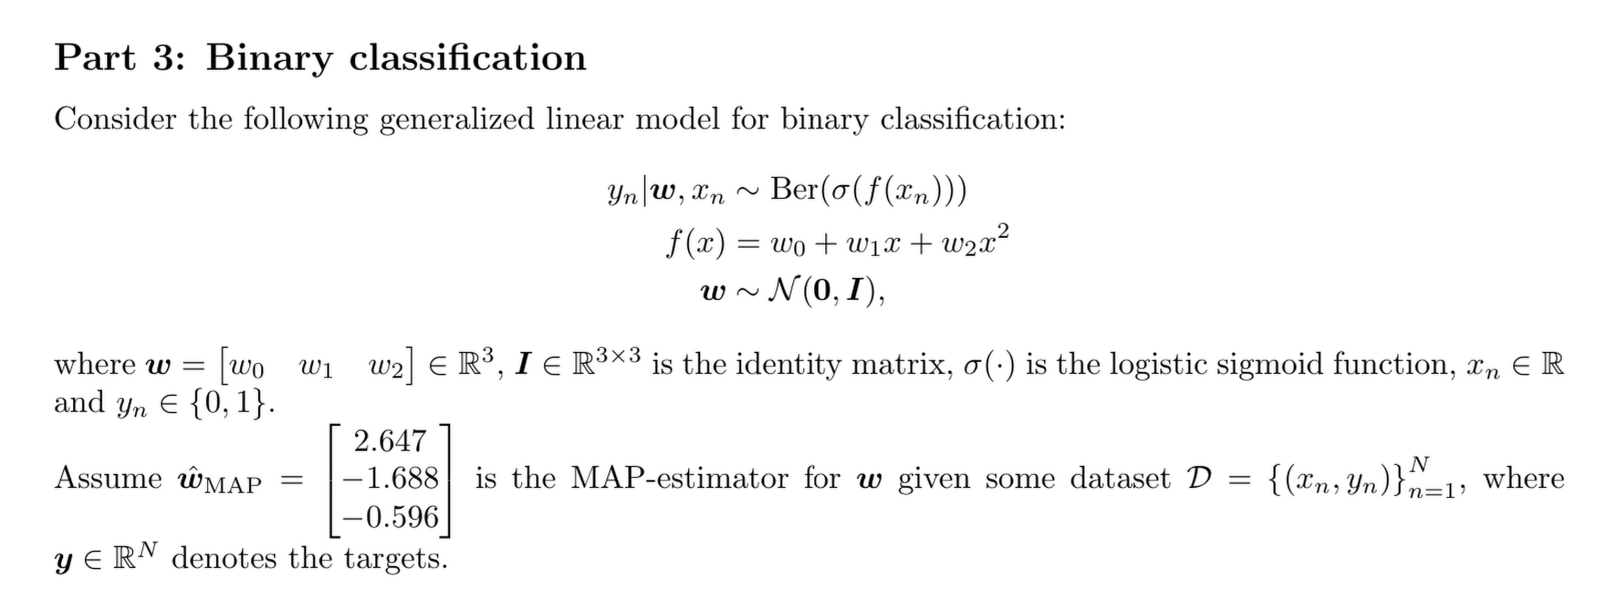

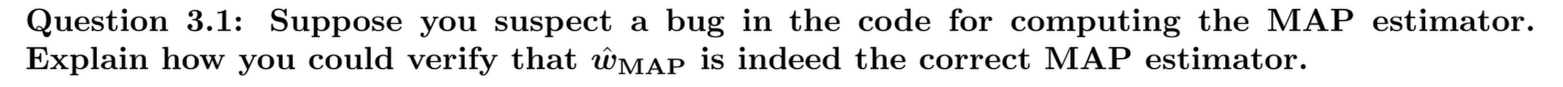

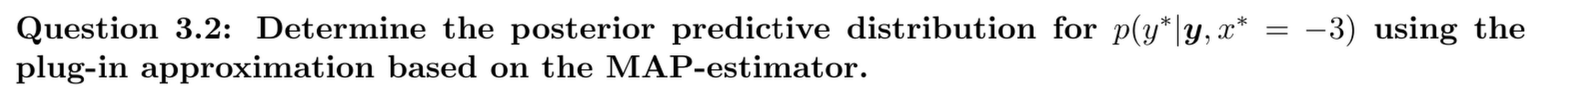

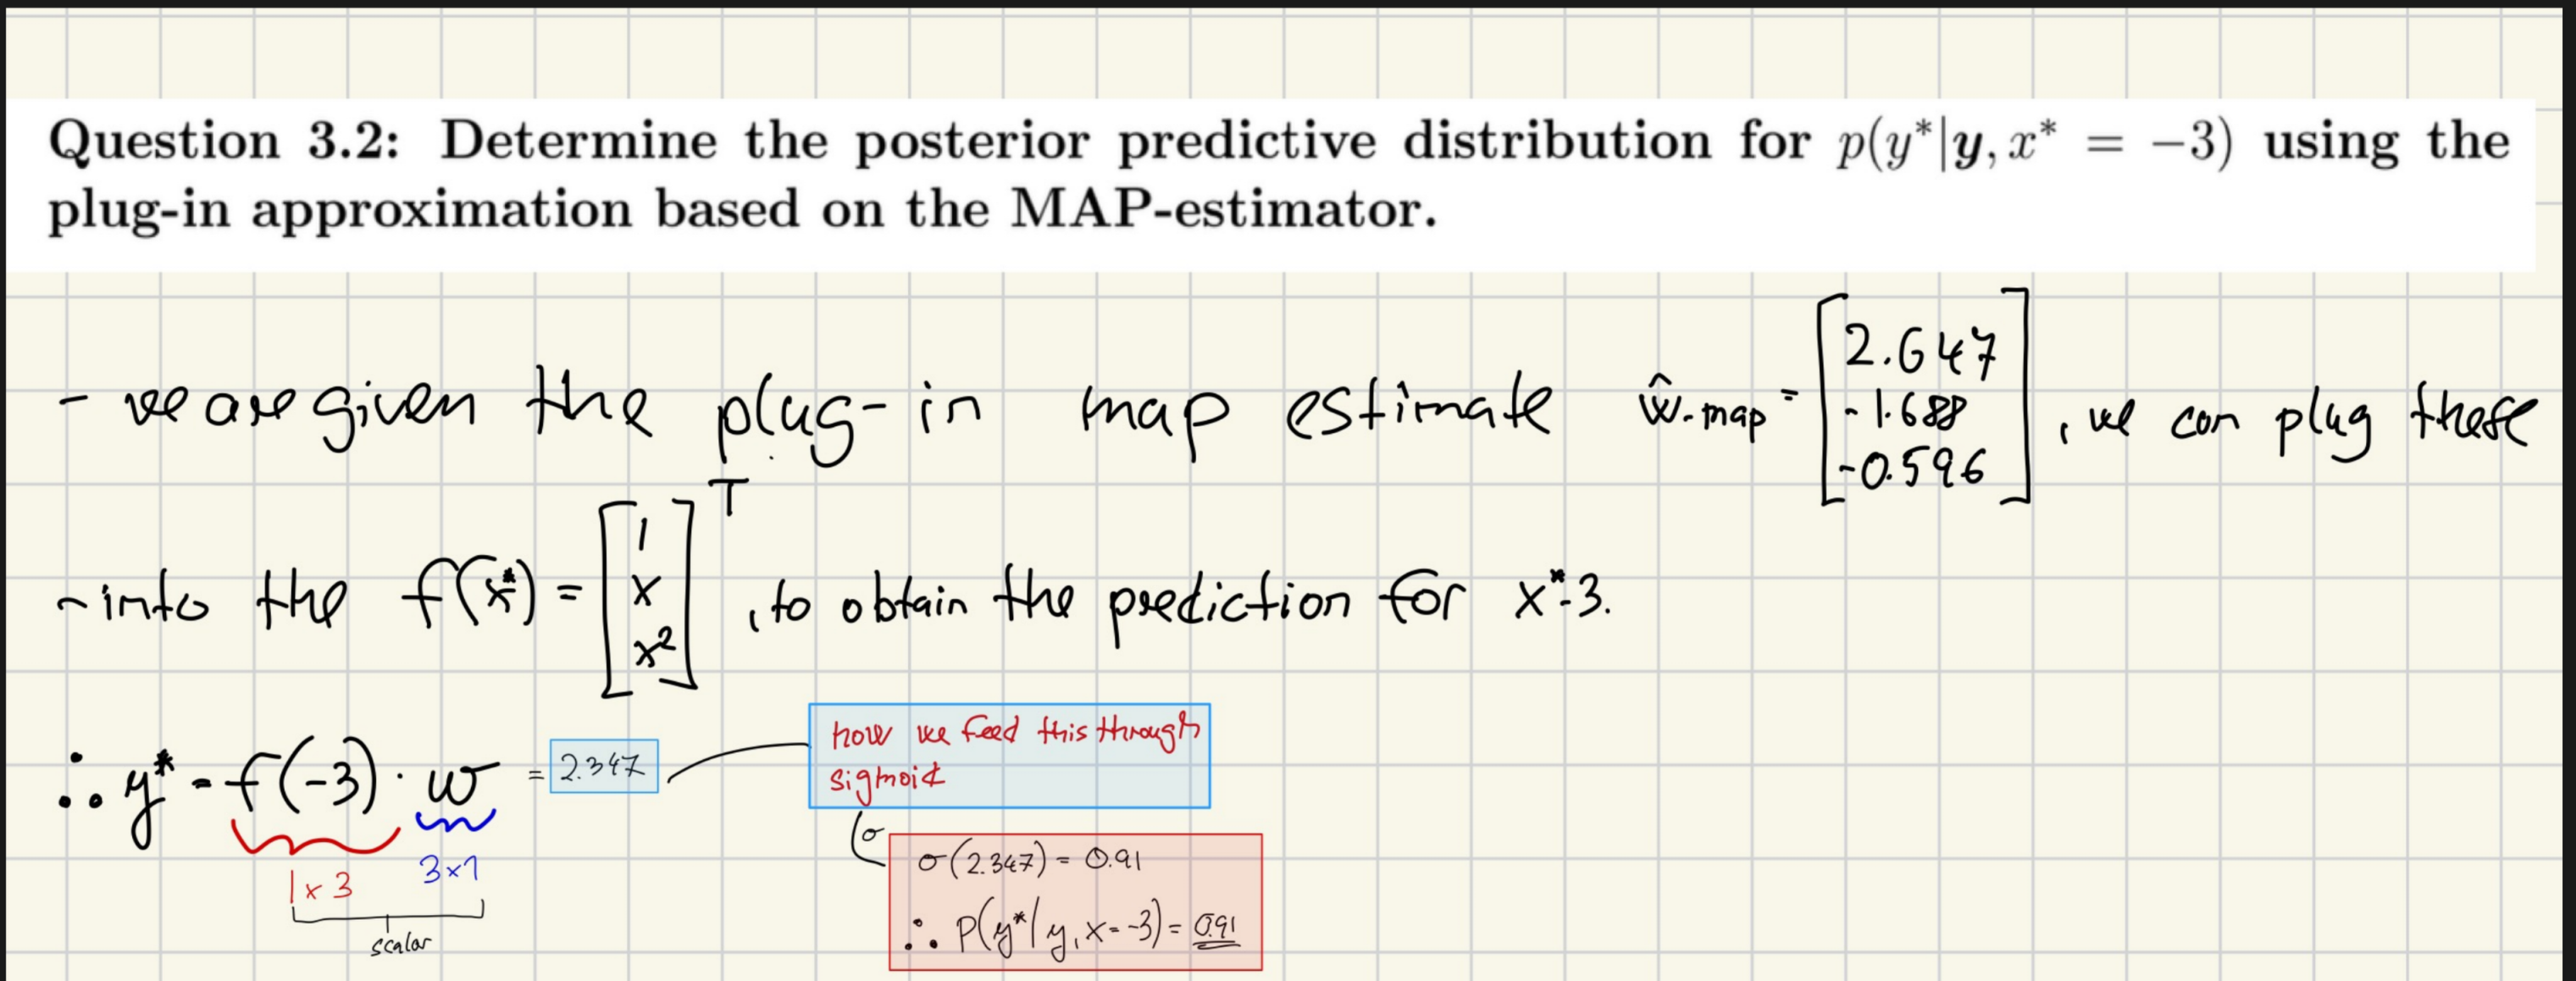

In [7]:
# 
w_map = jnp.array([2.647, -1.688, -0.596]).reshape(-1, 1)

f_x = lambda x, w: w[0] + w[1] * x + w[2] * x**2

In [8]:
post_pred = f_x(x=-3, w=w_map)

In [9]:
def sigmoid(x):
    return 1 / (1 + jnp.exp(-x))

In [10]:
print(sigmoid(post_pred))

[0.91269548]


#### Vectorized solution:  

In [11]:
def design_matrix(x):
    """
    Φ(x) = [1, x, x²]      ← quadratic trend basis
    Feel free to uncomment seasonal cosine terms etc.
    """
    return jnp.column_stack((jnp.ones(len(x)), x, x**2)) 

x_star = jnp.array([-3]).reshape(-1, 1)


f_x = design_matrix(x_star)
print(f"Shape of the design matrix {f_x.shape}")
print(f"Design_matrix = {f_x}")
print(f"Shape of w_map = {w_map.shape}")
print(f"w_map = {w_map}")
y_star_map = f_x @ w_map


print(y_star_map)

print(sigmoid((y_star_map)))

Shape of the design matrix (1, 3)
Design_matrix = [[ 1. -3.  9.]]
Shape of w_map = (3, 1)
w_map = [[ 2.647]
 [-1.688]
 [-0.596]]
[[2.347]]
[[0.91269548]]


In [12]:
import jax

mu = w_map[0]
sigma = jnp.sqrt(3)
key = jax.random.PRNGKey(42)

samples = mu + sigma * jax.random.normal(key, shape=(10**6,))


interval = jnp.percentile(samples, jnp.array([5, 95]))
print(f'95% credibility interval: [{interval[0]:.2f}, {interval[1]:.2f}]\t(estimated using sampling)')


95% credibility interval: [-0.20, 5.49]	(estimated using sampling)


In [13]:
S = jnp.array([
    [3.0, -0.39, -0.3],
    [-0.39, 1.55, 0.37], 
    [-0.3, 0.37, 0.14]
    ])
print(f"Shape of w_map = {w_map.shape}")
print(f"Shape of x_star = {f_x.shape}")


posterior_f_mean = w_map.T @ f_x.T
print(f"Posterior mean {posterior_f_mean}")

posterior_f_variance = f_x @ S @ f_x.T
print(f"Posterior variance {posterior_f_variance}")

Shape of w_map = (3, 1)
Shape of x_star = (1, 3)
Posterior mean [[2.347]]
Posterior variance [[5.25]]


In [14]:
from scipy.stats import norm as norm_dist

probit = lambda x: norm_dist.cdf(x)

y_star = lambda m, v: probit(m/jnp.sqrt(8/jnp.pi + v))


print(y_star(posterior_f_mean, posterior_f_variance))

[[0.79970011]]


In [16]:
print(sigmoid(posterior_f_mean))

[[0.91269548]]


In [19]:
U = jnp.array([[2, 1], 
           [1, 2]])
p_hat = jnp.array([0.129, 1 - 0.129]) 

print(compute_expected_utility(U, p_hat))

[1.129 1.871]


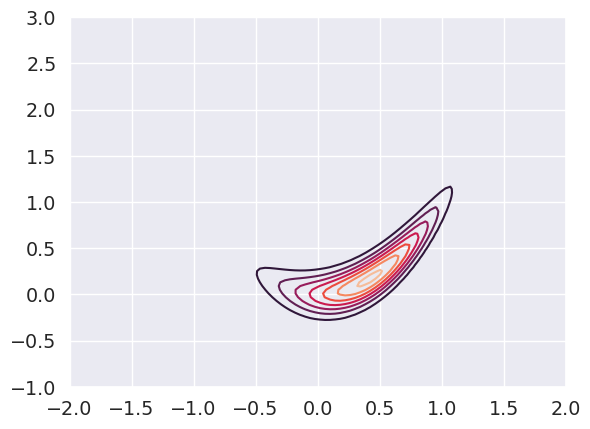

In [37]:
def log_joint(z_1, z_2): 
    return - (1 - z_1)**2 - 20 * (z_2 - z_1**2)**2 - z_1**2 - z_2**2 
    

v_func = jnp.vectorize(log_joint)

x, y = jnp.meshgrid(jnp.linspace(-2, 2, 100),
                     jnp.linspace(-1, 3, 100))

fig, ax = plt.subplots(1)
ax.contour(x, y, jnp.exp(v_func(x, y)))
plt.show()

In [40]:
num_alpha, num_beta = 90, 100
alphas = jnp.linspace(-4, 4, num_alpha)  # Shape: (90,) - intercept parameter range
betas = jnp.linspace(-4, 4, num_beta)    # Shape: (100,) - slope parameter range

%matplotlib inline
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
from jax import random
import seaborn as snb

# distributions
from scipy.stats import norm
from scipy.stats import multivariate_normal as mvn
from scipy.stats import poisson

# for plotting and visualization
from exercise8 import plot_predictions
from exercise8 import eval_density_grid

# style stuff
snb.set_style('darkgrid')
snb.set(font_scale=1.25)


In [41]:
def metropolis(log_target, num_params, tau, num_iter, theta_init=None, seed=0):
    """
    Run the Metropolis-Hastings MCMC algorithm to draw samples from a target distribution.

    Parameters
    ----------
    log_target : callable
        Function that evaluates the log of the unnormalized target distribution.
        Input shape: (num_params,) → Output shape: () (scalar)
        Should return log(p(theta)) up to a constant.

    num_params : int
        Number of parameters (dimensionality of theta ∈ R^D).

    tau : float
        Standard deviation of the Gaussian proposal distribution.
        Proposal: theta_star = theta_cur + tau * epsilon, where epsilon ~ N(0, I).
        Must be > 0.

    num_iter : int
        Number of sampling steps (excluding the initial sample).

    theta_init : jnp.ndarray of shape (num_params,), optional
        Starting point of the Markov chain. If None, initializes at zero.

    seed : int
        Seed for JAX's random number generator to ensure reproducibility.

    Returns
    -------
    thetas : jnp.ndarray, shape = (num_iter + 1, num_params)
        All MCMC samples including the initial point. Each row is a sample.

    Notes
    -----
    The algorithm follows the Metropolis-Hastings logic:
      1. Sample proposal: theta_star = theta_cur + tau * epsilon
      2. Compute acceptance ratio: r = p(theta_star) / p(theta_cur)
         (done in log domain as log_r = log_p_star - log_p_cur)
      3. Accept with probability A = min(1, exp(log_r))
         - If accepted: move to theta_star
         - If rejected: stay at theta_cur

    Shapes Summary
    --------------
    - theta_init          : (num_params,)
    - theta_cur           : (num_params,)
    - theta_star          : (num_params,)
    - epsilon             : (num_params,)
    - thetas              : (num_iter + 1, num_params)
    - accepts             : (num_iter,) (list of integers: 0 or 1)

    Examples
    --------

    # 1. Sample from 1D Gaussian N(1, 3)
    >>> def log_npdf(x, mu, var):
    ...     return -0.5 * jnp.log(2 * jnp.pi * var) - 0.5 * ((x - mu) ** 2) / var
    >>> log_target = lambda x: log_npdf(x, 1.0, 3.0)
    >>> samples = metropolis(log_target, num_params=1, tau=2.0, num_iter=10000)
    >>> print(jnp.mean(samples), jnp.var(samples))  # Should be ~1 and ~3

    # 2. Sample from 2D standard Gaussian N([0, 0], I)
    >>> def log_target_2d(x):
    ...     return -0.5 * jnp.sum(x**2) - jnp.log(2 * jnp.pi)
    >>> samples_2d = metropolis(log_target_2d, num_params=2, tau=1.0, num_iter=10000)

    # 3. Sample from 10D Gaussian with diagonal covariance
    >>> mu = jnp.linspace(0, 9, 10)
    >>> var = jnp.ones(10) * 2.0
    >>> def log_nd_10(x):
    ...     return -0.5 * jnp.sum((x - mu)**2 / var) - 0.5 * jnp.sum(jnp.log(2 * jnp.pi * var))
    >>> samples_10d = metropolis(log_nd_10, num_params=10, tau=1.0, num_iter=5000)

    # 4. Banana-shaped distribution (non-Gaussian)
    >>> def log_banana(x):
    ...     x1, x2 = x[0], x[1]
    ...     return -x1**2 / 200 - 0.5 * (x2 + 0.03 * x1**2 - 3)**2
    >>> samples_banana = metropolis(log_banana, num_params=2, tau=1.5, num_iter=20000)

    # 5. Discrete-like distribution (e.g. log-prob that spikes)
    >>> def log_spiky(x):
    ...     return -10 * jnp.floor(x[0])**2
    >>> samples_spiky = metropolis(log_spiky, num_params=1, tau=0.5, num_iter=10000)

    Tips
    ----
    - Monitor the printed acceptance ratio. Good values are typically between 20% and 40%.
    - Use small `tau` if most proposals are rejected; use larger `tau` if almost all are accepted (may indicate slow exploration).
    - Burn-in and thinning are optional post-processing steps depending on your use case.

    """
    # -------------------------------------------------------
    # !Initialize random number generator
    # -------------------------------------------------------
    key = random.PRNGKey(seed)

    # -------------------------------------------------------
    # !Set starting point (default = 0 vector)
    # -------------------------------------------------------
    if theta_init is None:
        theta_init = jnp.zeros((num_params,))  # shape (num_params,)

    # -------------------------------------------------------
    # !Prepare containers for MCMC samples and acceptances
    # -------------------------------------------------------
    thetas = [theta_init]         # list of samples: each is (num_params,)
    accepts = []                  # list of 0/1 indicators

    # Evaluate log of target at initial point
    log_p_theta = log_target(theta_init)

    for k in range(num_iter):

        # -------------------------------------------------------
        # !Split key into proposal and acceptance subkeys
        # -------------------------------------------------------
        key, key_proposal, key_accept = random.split(key, num=3)

        # -------------------------------------------------------
        # !Sample from proposal distribution:
        #   theta_star = theta_cur + tau * epsilon
        # -------------------------------------------------------
        theta_cur = thetas[-1]                                 # shape (num_params,)
        epsilon = random.normal(key_proposal, shape=(num_params,))  # shape (num_params,)
        theta_star = theta_cur + tau * epsilon                 # shape (num_params,)

        # -------------------------------------------------------
        # !Compute acceptance probability: A = min(1, exp(log_r))
        # -------------------------------------------------------
        log_p_theta_star = log_target(theta_star)              # scalar
        log_r = log_p_theta_star - log_p_theta
        A = jnp.minimum(1.0, jnp.exp(log_r))                   # scalar ∈ [0, 1]

        # -------------------------------------------------------
        # !Accept or reject the proposal
        # -------------------------------------------------------
        u = random.uniform(key_accept)
        if u < A:
            # Accept the proposal
            theta_next = theta_star
            log_p_theta = log_p_theta_star
            accepts.append(1)
        else:
            # Reject the proposal
            theta_next = theta_cur
            accepts.append(0)

        # -------------------------------------------------------
        # !Append the new sample to the chain
        # -------------------------------------------------------
        thetas.append(theta_next)

    # -------------------------------------------------------
    # !Report acceptance rate (useful for diagnostics)
    # -------------------------------------------------------
    acceptance_rate = jnp.mean(jnp.array(accepts))
    print(f"Acceptance ratio: {acceptance_rate:.2f}")

    # -------------------------------------------------------
    # !Convert list to array of shape (num_iter + 1, num_params)
    # -------------------------------------------------------
    print(len(thetas))
    thetas = jnp.stack(thetas)
    print(thetas.shape)
    # -------------------------------------------------------
    # !Shape check for debugging
    # -------------------------------------------------------
    assert thetas.shape == (num_iter + 1, num_params), (
        f"Expected shape {(num_iter + 1, num_params)}, but got {thetas.shape}"
    )

    return thetas

In [56]:
from jax import random
# Define the log-target density: log of a Gaussian N(x | mean=1, var=3)
# Input: x ∈ ℝ¹ (shape: (1,))
# Output: scalar log-density value (float)
def log_joint(z):
    z_1 = z[0]
    z_2 = z[1] 
    return - (1 - z_1)**2 - 20 * (z_2 - z_1**2)**2 - z_1**2 - z_2**2 

# Run the Metropolis-Hastings sampler to generate samples from the target distribution
# Arguments:
# - p_target       : log-density function
# - num_params     : 1 parameter (scalar x)
# - tau            : standard deviation of the proposal (τ = 2.0)
# - num_iter       : number of MCMC steps (20,000 samples)
# - theta_init     : initial point (x₀ = 0.0), shape = (1,)
# Output:
# - thetas         : array of samples from Markov chain, shape = (20001, 1)
thetas = metropolis(log_joint, 2, 1., 10**4, theta_init=jnp.array([0, 1.5]), seed=1)

Acceptance ratio: 0.09
10001
(10001, 2)


In [57]:
z1 = thetas[:, 0]
z2 = thetas[:, 1]

In [58]:
print(f"Posterior mean of sin(z1z2) = {jnp.mean(jnp.sin(z1 * z2)):.2f}")

Posterior mean of sin(z1z2) = 0.15


In [59]:
print(f"Posterior mean of p(z1 > z2 |D) = {jnp.mean(z1 > z2):.2f}")

Posterior mean of p(z1 > z2 |D) = 0.75
